In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load datasets

anime_df = pd.read_csv("anime.csv")
rating_df = pd.read_csv("rating.csv")

print("Anime Dataset Shape:", anime_df.shape)
print("Rating Dataset Shape:", rating_df.shape)

Anime Dataset Shape: (12294, 7)
Rating Dataset Shape: (7813737, 3)


In [3]:
# Display first 5 rows

anime_df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
rating_df.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [5]:
print("Anime Columns:")
print(anime_df.columns)

print("\nRating Columns:")
print(rating_df.columns)

Anime Columns:
Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

Rating Columns:
Index(['user_id', 'anime_id', 'rating'], dtype='object')


In [6]:
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [7]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [8]:
anime_df.describe(include='all')

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Saru Kani Gassen,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [9]:
# Missing values in anime dataset

anime_df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [10]:
# Percentage of missing values

missing_anime = pd.DataFrame({
    'Missing Count': anime_df.isnull().sum(),
    'Missing Percentage': anime_df.isnull().mean() * 100
})

missing_anime

,Missing Count,Missing Percentage
anime_id,0,0.000000
name,0,0.000000
genre,62,0.504311
type,25,0.203351
episodes,0,0.000000
rating,230,1.870831
members,0,0.000000


In [11]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [12]:
print("Duplicate rows in anime dataset:",
      anime_df.duplicated().sum())

print("Duplicate rows in rating dataset:",
      rating_df.duplicated().sum())

Duplicate rows in anime dataset: 0
Duplicate rows in rating dataset: 1


In [13]:
for col in anime_df.columns:
    print("\n", col)
    print("Number of unique values:", anime_df[col].nunique())
    print(anime_df[col].unique()[:10])


 anime_id
Number of unique values: 12294
[32281  5114 28977  9253  9969 32935 11061   820 15335 15417]

 name
Number of unique values: 12292
['Kimi no Na wa.' 'Fullmetal Alchemist: Brotherhood' 'Gintama°'
 'Steins;Gate' 'Gintama&#039;'
 'Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou'
 'Hunter x Hunter (2011)' 'Ginga Eiyuu Densetsu'
 'Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare'
 'Gintama&#039;: Enchousen']

 genre
Number of unique values: 3264
['Drama, Romance, School, Supernatural'
 'Action, Adventure, Drama, Fantasy, Magic, Military, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Sci-Fi, Thriller' 'Comedy, Drama, School, Shounen, Sports'
 'Action, Adventure, Shounen, Super Power'
 'Drama, Military, Sci-Fi, Space'
 'Drama, Fantasy, Romance, Slice of Life, Supernatural'
 'Drama, School, Shounen'
 'Action, Drama, Mecha, Military, Sci-Fi, Super Power']

 type
Number of unique values: 6
['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA' nan]

 epi

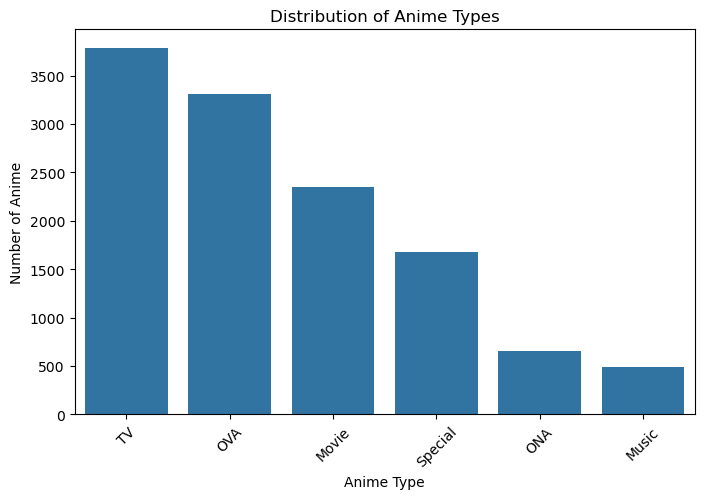

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=anime_df,
    x='type',
    order=anime_df['type'].value_counts().index
)

plt.title("Distribution of Anime Types")
plt.xlabel("Anime Type")
plt.ylabel("Number of Anime")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Remove missing genres

genre_df = anime_df.dropna(subset=['genre']).copy()

# Split genres and count them

genre_counts = (
    genre_df['genre']
    .str.split(', ')
    .explode()
    .value_counts()
)

genre_counts.head(20)

genre
Comedy           4645
Action           2845
Adventure        2348
Fantasy          2309
Sci-Fi           2070
Drama            2016
Shounen          1712
Kids             1609
Romance          1464
School           1220
Slice of Life    1220
Hentai           1141
Supernatural     1037
Mecha             944
Music             860
Historical        806
Magic             778
Ecchi             637
Shoujo            603
Seinen            547
Name: count, dtype: int64

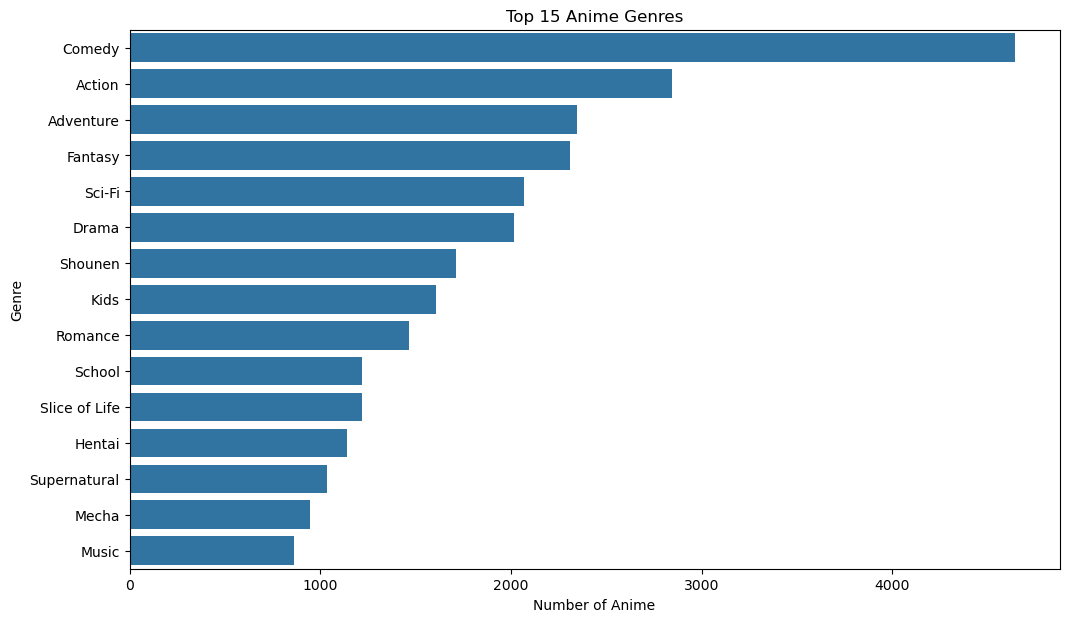

In [16]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=genre_counts.head(15).values,
    y=genre_counts.head(15).index
)

plt.title("Top 15 Anime Genres")
plt.xlabel("Number of Anime")
plt.ylabel("Genre")
plt.show()

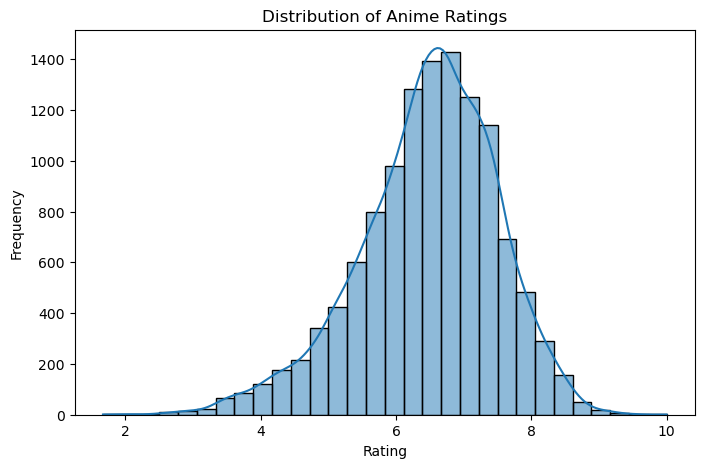

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    anime_df['rating'].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

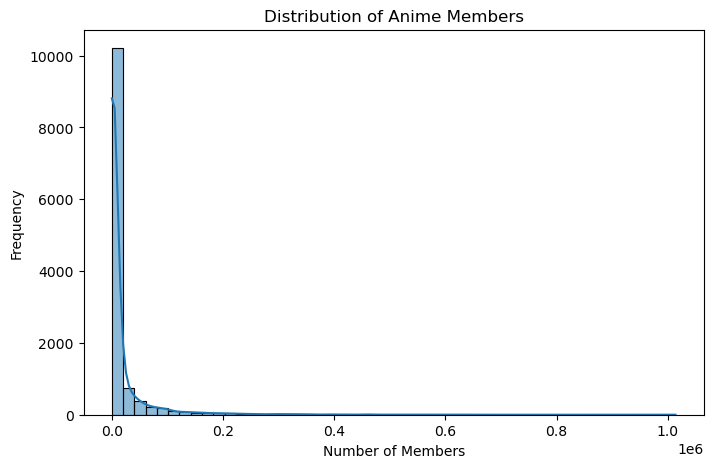

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    anime_df['members'],
    bins=50,
    kde=True
)

plt.title("Distribution of Anime Members")
plt.xlabel("Number of Members")
plt.ylabel("Frequency")
plt.show()

In [19]:
anime_df['episodes_num'] = pd.to_numeric(
    anime_df['episodes'],
    errors='coerce'
)

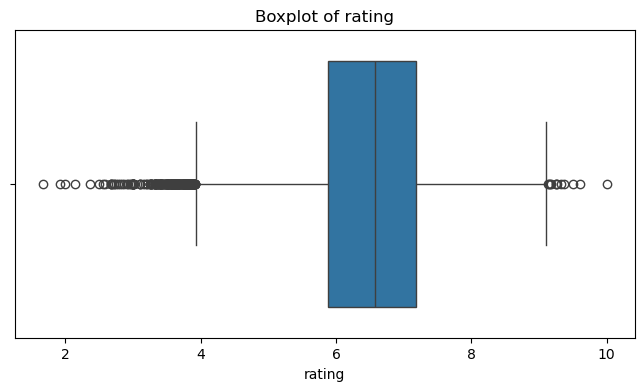

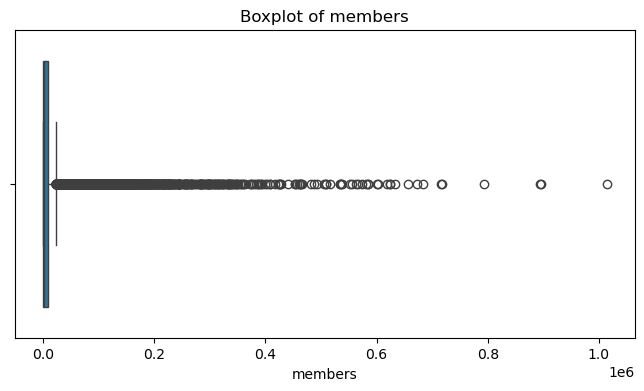

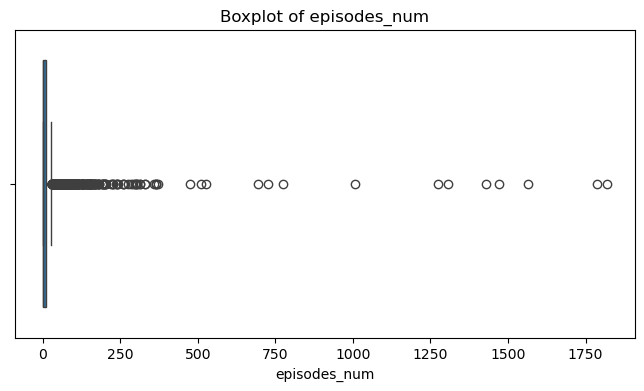

In [20]:
numeric_cols = [
    'rating',
    'members',
    'episodes_num'
]

for col in numeric_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=anime_df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.show()

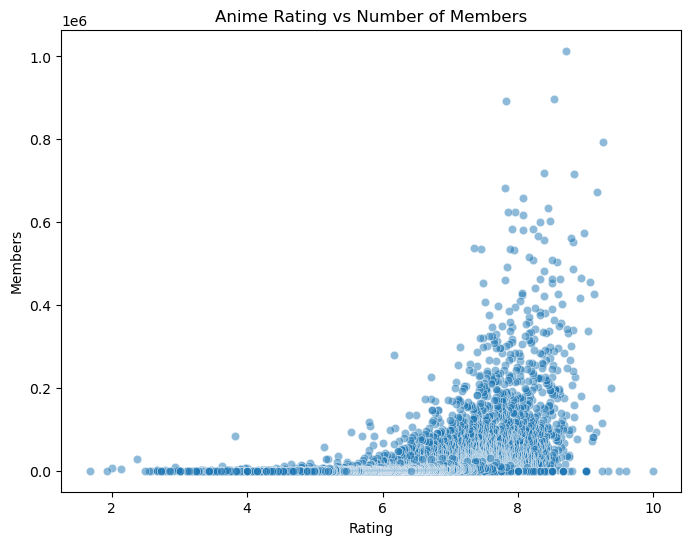

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=anime_df,
    x='rating',
    y='members',
    alpha=0.5
)

plt.title("Anime Rating vs Number of Members")
plt.xlabel("Rating")
plt.ylabel("Members")
plt.show()

In [22]:
type_rating = (
    anime_df
    .groupby('type')['rating']
    .mean()
    .sort_values(ascending=False)
)

type_rating

type
TV         6.902299
Special    6.523501
OVA        6.375221
Movie      6.318058
ONA        5.643298
Music      5.588996
Name: rating, dtype: float64

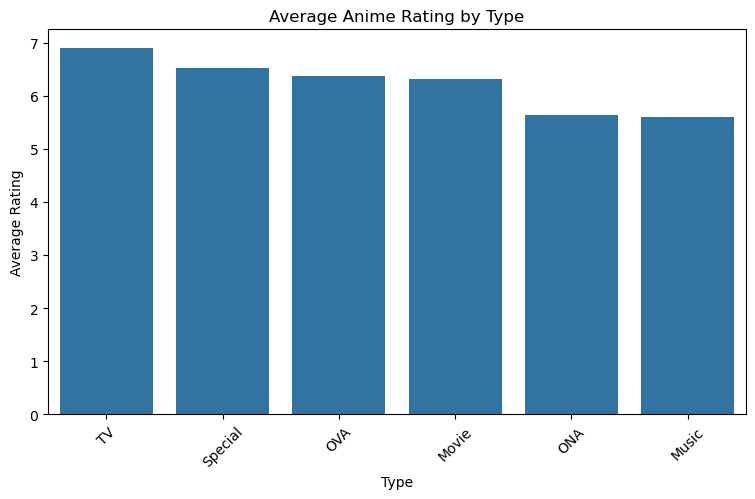

In [23]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=type_rating.index,
    y=type_rating.values
)

plt.title("Average Anime Rating by Type")
plt.xlabel("Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.show()

In [24]:
anime_df['episodes_num'] = pd.to_numeric(
    anime_df['episodes'],
    errors='coerce'
)

In [25]:
anime_df[['episodes', 'episodes_num']].head(20)

,episodes,episodes_num
0,1,1.0
1,64,64.0
2,51,51.0
3,24,24.0
4,51,51.0
5,10,10.0
6,148,148.0
7,110,110.0
8,1,1.0
9,13,13.0


In [26]:
numeric_cols = [
    'rating',
    'members',
    'episodes_num'
]

skewness = anime_df[numeric_cols].skew()

print("Skewness of numerical variables:")
print(skewness)

Skewness of numerical variables:
rating          -0.543570
members          6.682934
episodes_num    23.385641
dtype: float64


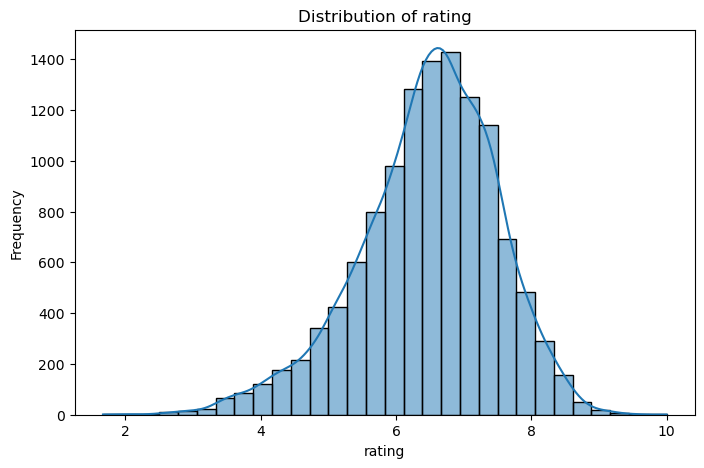

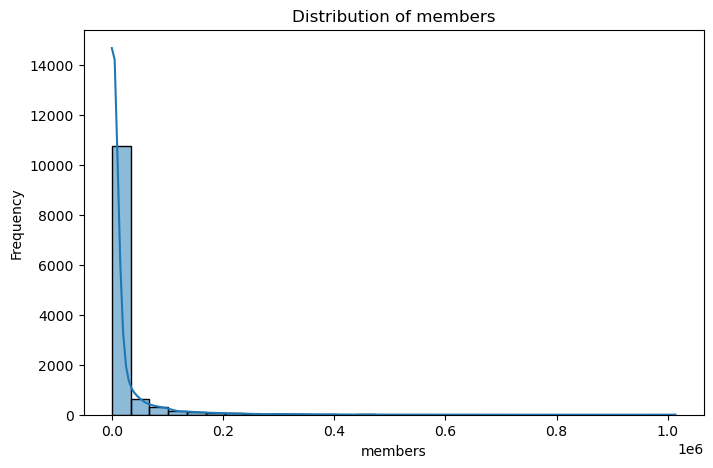

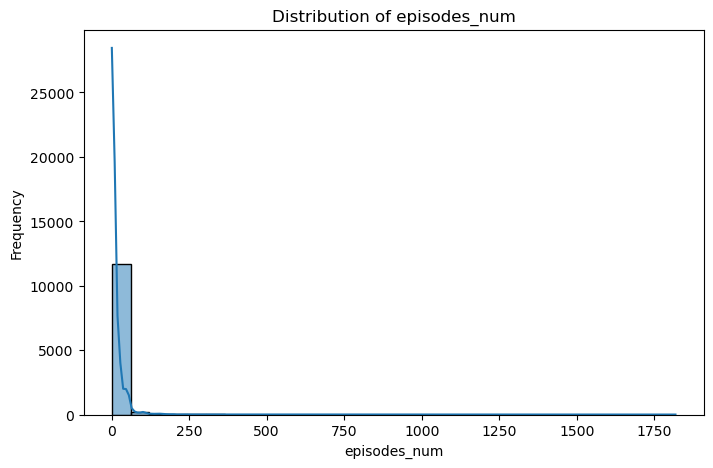

In [27]:
for col in numeric_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(
        anime_df[col].dropna(),
        kde=True,
        bins=30
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

In [28]:
anime_df['members_log'] = np.log1p(anime_df['members'])

In [29]:
anime_df['episodes_log'] = np.log1p(
    anime_df['episodes_num']
)

In [30]:
transformed_cols = [
    'members_log',
    'episodes_log'
]

print("Before transformation:")
print(anime_df[['members', 'episodes_num']].skew())

print("\nAfter transformation:")
print(anime_df[transformed_cols].skew())

Before transformation:
members          6.682934
episodes_num    23.385641
dtype: float64

After transformation:
members_log     0.266096
episodes_log    1.012310
dtype: float64


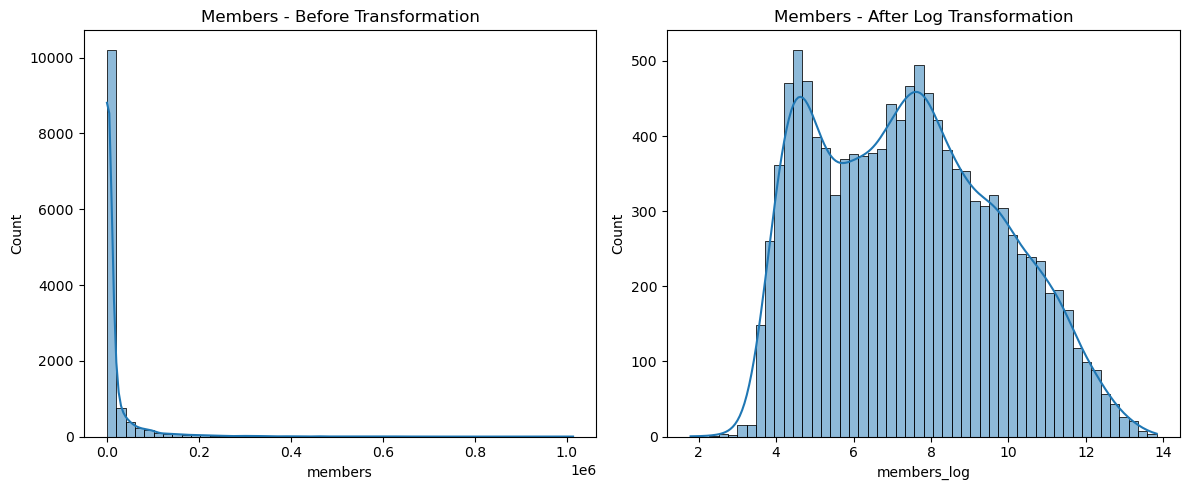

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    anime_df['members'],
    bins=50,
    kde=True
)

plt.title("Members - Before Transformation")


plt.subplot(1,2,2)

sns.histplot(
    anime_df['members_log'],
    bins=50,
    kde=True
)

plt.title("Members - After Log Transformation")

plt.tight_layout()
plt.show()

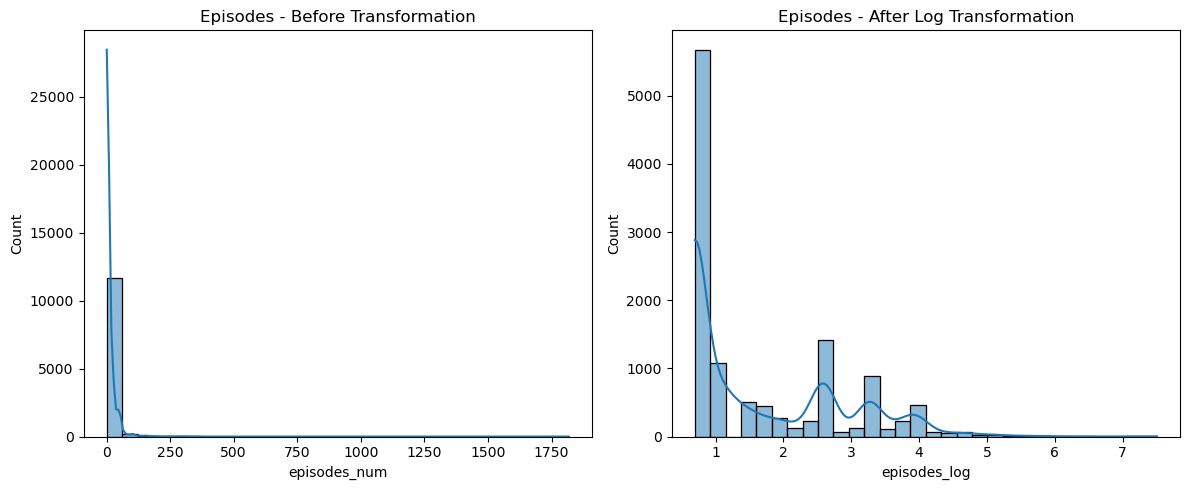

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    anime_df['episodes_num'].dropna(),
    bins=30,
    kde=True
)

plt.title("Episodes - Before Transformation")


plt.subplot(1,2,2)

sns.histplot(
    anime_df['episodes_log'].dropna(),
    bins=30,
    kde=True
)

plt.title("Episodes - After Log Transformation")

plt.tight_layout()
plt.show()

In [33]:
Q1 = anime_df['members'].quantile(0.25)
Q3 = anime_df['members'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = anime_df[
    (anime_df['members'] < lower_bound) |
    (anime_df['members'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1900


In [34]:
# Create a copy

anime_rec = anime_df.copy()

# Fill missing values

anime_rec['genre'] = anime_rec['genre'].fillna('Unknown')
anime_rec['type'] = anime_rec['type'].fillna('Unknown')
anime_rec['rating'] = anime_rec['rating'].fillna(
    anime_rec['rating'].median()
)

anime_rec['members_log'] = anime_rec['members_log'].fillna(0)

In [35]:
tfidf = TfidfVectorizer(
    token_pattern=r'[^,]+',
    lowercase=True
)

genre_matrix = tfidf.fit_transform(
    anime_rec['genre']
)

print("Genre Matrix Shape:", genre_matrix.shape)

Genre Matrix Shape: (12294, 83)


In [36]:
type_encoder = OneHotEncoder(
    sparse_output=True,
    handle_unknown='ignore'
)

type_matrix = type_encoder.fit_transform(
    anime_rec[['type']]
)

print("Type Matrix Shape:", type_matrix.shape)

Type Matrix Shape: (12294, 7)


In [37]:
numeric_features = anime_rec[
    ['rating', 'members_log']
].values

scaler = StandardScaler()

numeric_matrix = scaler.fit_transform(
    numeric_features
)

In [38]:
from scipy.sparse import csr_matrix

numeric_matrix = csr_matrix(numeric_matrix)

In [39]:
from scipy.sparse import hstack

feature_matrix = hstack([
    genre_matrix,
    type_matrix,
    numeric_matrix
]).tocsr()

print("Final Feature Matrix Shape:")
print(feature_matrix.shape)

Final Feature Matrix Shape:
(12294, 92)


In [40]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(feature_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [41]:
def recommend_anime(anime_name, n_recommendations=10):
    
    # Find anime index
    matches = anime_rec[
        anime_rec['name'].str.lower() == anime_name.lower()
    ]
    
    if matches.empty:
        print("Anime not found.")
        return
    
    anime_index = matches.index[0]
    
    # Find nearest anime
    distances, indices = model.kneighbors(
        feature_matrix[anime_index],
        n_neighbors=n_recommendations + 1
    )
    
    # Remove the input anime itself
    recommended_indices = indices.flatten()[1:]
    recommended_distances = distances.flatten()[1:]
    
    recommendations = anime_rec.iloc[
        recommended_indices
    ][[
        'name',
        'genre',
        'type',
        'rating',
        'members'
    ]].copy()
    
    recommendations['similarity'] = (
        1 - recommended_distances
    )
    
    return recommendations.reset_index(drop=True)

In [42]:
recommend_anime(
    "Naruto",
    10
)

,name,genre,type,rating,members,similarity
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,0.998701
1,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,316102,0.972899
2,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,375662,0.972683
3,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,624055,0.971534
4,Dragon Ball Super,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.40,111443,0.971325
5,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,116832,0.965407
6,Ben-To,"Action, Comedy, Martial Arts",TV,7.49,146570,0.964579
7,Medaka Box,"Action, Comedy, Ecchi, Martial Arts, School, S...",TV,7.21,110042,0.961120
8,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,8.37,258103,0.957820
9,Kurokami The Animation,"Action, Martial Arts, Super Power",TV,7.29,72750,0.957442
